# Phase 1: Data Loading & Understanding #

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dtype_map = {col: 'category' for col in ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']}
day_dtype = {f'd_{i}': 'int16' for i in range(1, 1942)}  # units sold fit in int16

sales_train_eval = pd.read_csv(
    'data/sales_train_evaluation.csv',
    dtype={**dtype_map, **day_dtype}
)
calendar = pd.read_csv('data/calendar.csv')
sales_train_eval = pd.read_csv('data/sales_train_evaluation.csv')
sales_train_val = pd.read_csv('data/sales_train_validation.csv')
sell_prices = pd.read_csv('data/sell_prices.csv')

In [5]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
sales_train_eval.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [7]:
sales_train_val.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [8]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [9]:
print(f"Calendar:              {calendar.shape}")
print(f"Sales (evaluation):    {sales_train_eval.shape}")
print(f"Sales (validation):    {sales_train_val.shape}")
print(f"Sell prices:           {sell_prices.shape}")

print(f"From {calendar['date'].min()} to {calendar['date'].max()}")

print(f"Items:      {sales_train_eval['item_id'].nunique()}")
print(f"Stores:     {sales_train_eval['store_id'].nunique()}")
print(f"Categories: {sales_train_eval['cat_id'].nunique()} -> {sales_train_eval['cat_id'].unique()}")
print(f"Depts:      {sales_train_eval['dept_id'].nunique()} -> {sales_train_eval['dept_id'].unique()}")
print(f"States:     {sales_train_eval['state_id'].nunique()} -> {sales_train_eval['state_id'].unique()}")

Calendar:              (1969, 14)
Sales (evaluation):    (30490, 1947)
Sales (validation):    (30490, 1919)
Sell prices:           (6841121, 4)
From 2011-01-29 to 2016-06-19
Items:      3049
Stores:     10
Categories: 3 -> <StringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str
Depts:      7 -> <StringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str
States:     3 -> <StringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str


In [10]:
print("\nCalendar:")
print(calendar.isnull().sum()[calendar.isnull().sum() > 0])
print("\nSell Prices:")
print(sell_prices.isnull().sum()[sell_prices.isnull().sum() > 0])

day_cols = [c for c in sales_train_eval.columns if c.startswith('d_')]
total_cells = sales_train_eval[day_cols].size
zero_cells = (sales_train_eval[day_cols] == 0).sum().sum()
print(f"\nSales data: {zero_cells / total_cells:.1%} of daily entries are zero")


Calendar:
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

Sell Prices:
Series([], dtype: int64)

Sales data: 68.0% of daily entries are zero


# Phase 2: Aggregate to Project Scope

We'll use the **evaluation** dataset (it has the most recent data, d_1 through d_1941).

Steps:
1. Aggregate item-level sales to **store × category** while still in wide format (30,490 rows → 30 rows)
2. Melt to long format (30 × 1,941 ≈ 58K rows — no memory issues)
3. Merge with calendar to get actual dates and week identifiers
4. Aggregate daily → **weekly** level
5. Filter to the most recent **2 years** of data

In [11]:
day_cols = [c for c in sales_train_eval.columns if c.startswith('d_')]

store_cat_wide = (
    sales_train_eval
    .groupby(['store_id', 'state_id', 'cat_id'])[day_cols]
    .sum()
    .reset_index()
)
print(f"Aggregated wide: {store_cat_wide.shape[0]} rows (store × category combos)")

sales_long = store_cat_wide.melt(
    id_vars=['store_id', 'state_id', 'cat_id'],
    value_vars=day_cols,
    var_name='d',
    value_name='units_sold'
)
sales_long.head()

/tmp/ipykernel_7070/2121014473.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


Aggregated wide: 30 rows (store × category combos)


,store_id,state_id,cat_id,d,units_sold
0,CA_1,CA,FOODS,d_1,3239
1,CA_1,CA,HOBBIES,d_1,556
2,CA_1,CA,HOUSEHOLD,d_1,542
3,CA_2,CA,FOODS,d_1,2193
4,CA_2,CA,HOBBIES,d_1,538


In [12]:
calendar['date'] = pd.to_datetime(calendar['date'])
sales_long = sales_long.merge(
    calendar[['d', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
              'event_name_1', 'event_type_1',
              'snap_CA', 'snap_TX', 'snap_WI']],
    on='d', how='left'
)

print(f"After merge: {sales_long.shape}")
sales_long.head()

After merge: (58230, 16)


,store_id,state_id,cat_id,d,units_sold,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI
0,CA_1,CA,FOODS,d_1,3239,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
1,CA_1,CA,HOBBIES,d_1,556,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
2,CA_1,CA,HOUSEHOLD,d_1,542,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
3,CA_2,CA,FOODS,d_1,2193,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
4,CA_2,CA,HOBBIES,d_1,538,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0


In [23]:
# Aggregate daily → weekly (data is already at store × category level)
weekly = (
    sales_long
    .groupby(['store_id', 'state_id', 'cat_id', 'wm_yr_wk'])
    .agg(
        weekly_units=('units_sold', 'sum'),
        week_start=('date', 'min'),
        n_days=('date', 'nunique'),  # sanity check — should be 7
    )
    .reset_index()
)

weekly.head()

,store_id,state_id,cat_id,wm_yr_wk,weekly_units,week_start,n_days
0,CA_1,CA,FOODS,11101,17774,2011-01-29,7
1,CA_1,CA,FOODS,11102,18319,2011-02-05,7
2,CA_1,CA,FOODS,11103,15515,2011-02-12,7
3,CA_1,CA,FOODS,11104,14860,2011-02-19,7
4,CA_1,CA,FOODS,11105,15253,2011-02-26,7


In [25]:
# Filter to last 2 years and drop the incomplete final week
cutoff = weekly['week_start'].max() - pd.DateOffset(years=2)
weekly = weekly[(weekly['week_start'] >= cutoff) & (weekly['n_days'] == 7)].copy()

# Phase 3: Exploratory Data Analysis

Now that we have our data at the right granularity (store × category × week, last 2 years), let's explore it.

In [26]:
weekly['weekly_units'].describe()

count     3120.000000
mean      8860.973397
std       7238.701875
min       1020.000000
25%       2907.250000
50%       6044.500000
75%      14362.250000
max      35530.000000
Name: weekly_units, dtype: float64

In [27]:
weekly.groupby('cat_id')['weekly_units'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,1040.0,17703.0,5201.0,8094.0,14345.0,16956.0,20178.0,35530.0
HOBBIES,1040.0,2557.0,799.0,1020.0,1936.0,2476.0,2940.0,4796.0
HOUSEHOLD,1040.0,6323.0,2261.0,2690.0,5044.0,6044.0,7000.0,15171.0


## 3.1 Distribution of Weekly Demand

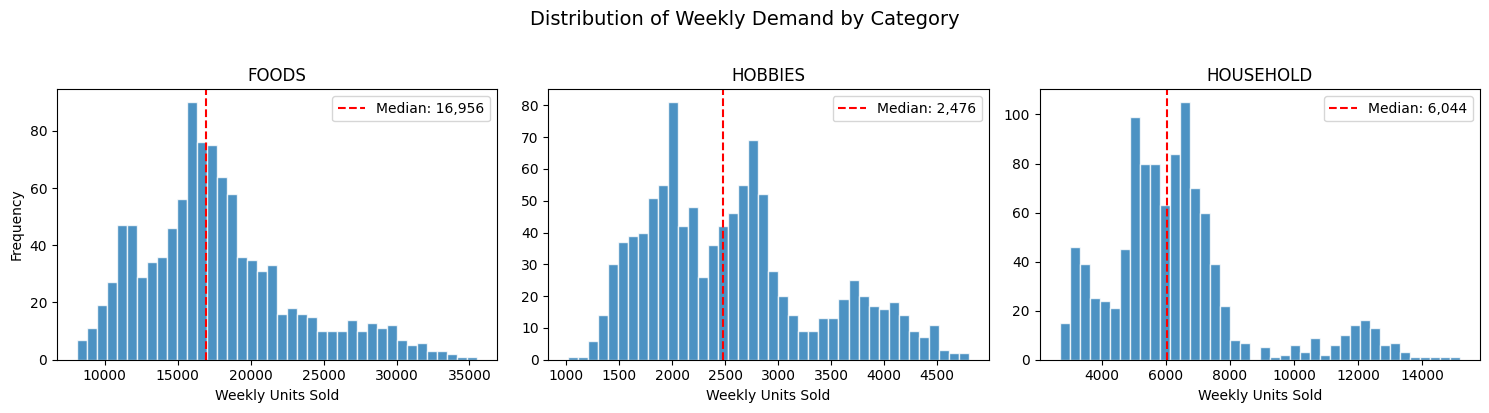

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, cat in zip(axes, sorted(weekly['cat_id'].unique())):
    data = weekly[weekly['cat_id'] == cat]['weekly_units']
    ax.hist(data, bins=40, edgecolor='white', alpha=0.8)
    ax.set_title(f'{cat}')
    ax.set_xlabel('Weekly Units Sold')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():,.0f}')
    ax.legend()

axes[0].set_ylabel('Frequency')
fig.suptitle('Distribution of Weekly Demand by Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

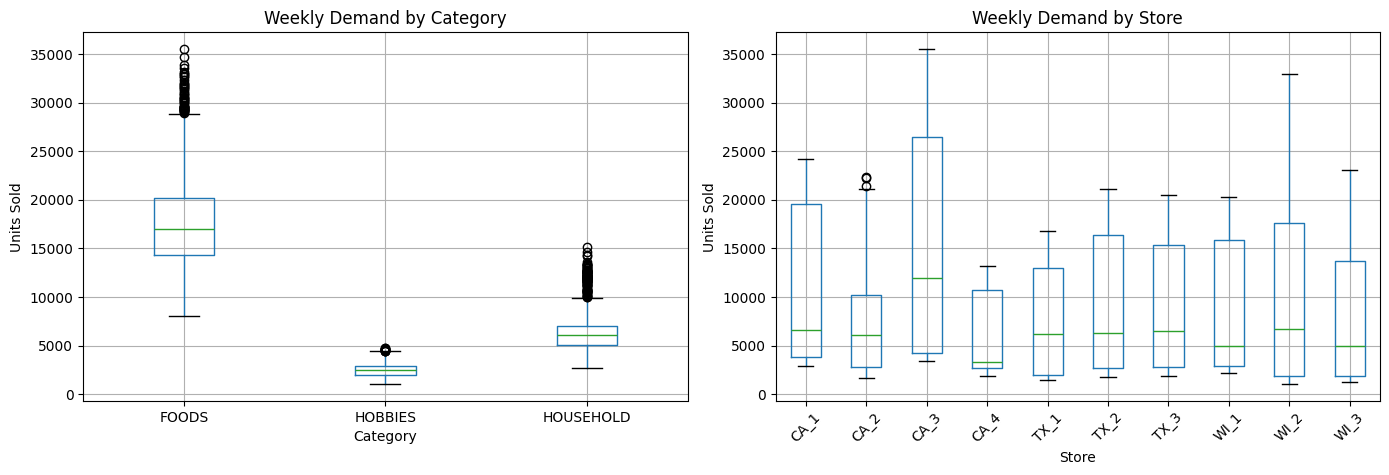

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weekly.boxplot(column='weekly_units', by='cat_id', ax=axes[0])
axes[0].set_title('Weekly Demand by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Units Sold')

weekly.boxplot(column='weekly_units', by='store_id', ax=axes[1])
axes[1].set_title('Weekly Demand by Store')
axes[1].set_xlabel('Store')
axes[1].set_ylabel('Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')  # remove automatic title from .boxplot()
plt.tight_layout()
plt.show()

## 3.2 Weekly Demand Trends Over Time

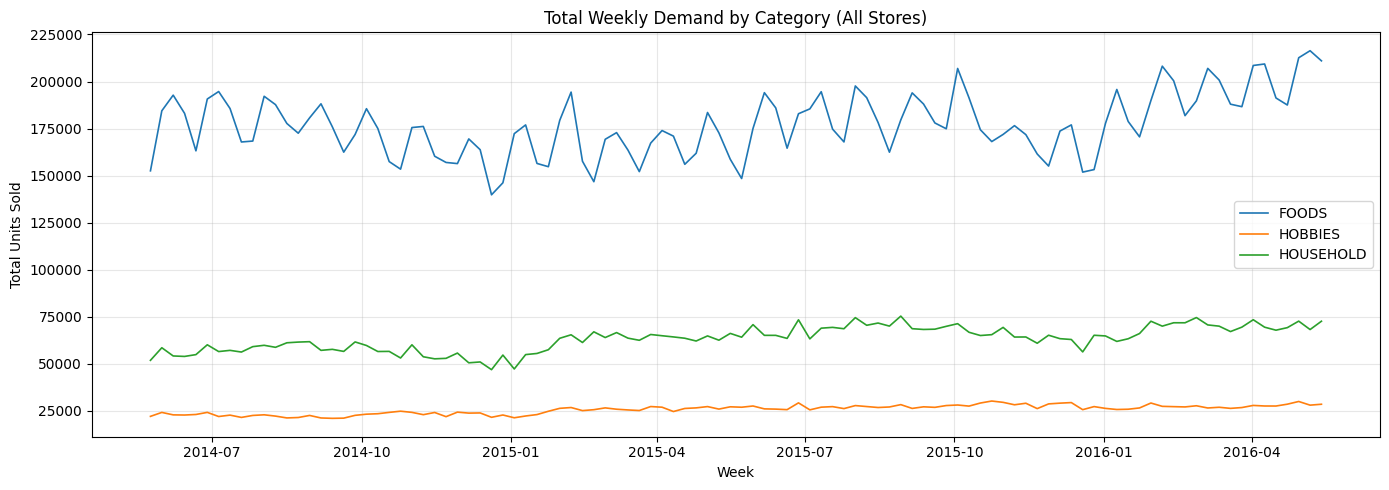

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))

for cat in sorted(weekly['cat_id'].unique()):
    cat_ts = weekly[weekly['cat_id'] == cat].groupby('week_start')['weekly_units'].sum().sort_index()
    ax.plot(cat_ts.index, cat_ts.values, label=cat, linewidth=1.2)

ax.set_title('Total Weekly Demand by Category (All Stores)')
ax.set_xlabel('Week')
ax.set_ylabel('Total Units Sold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

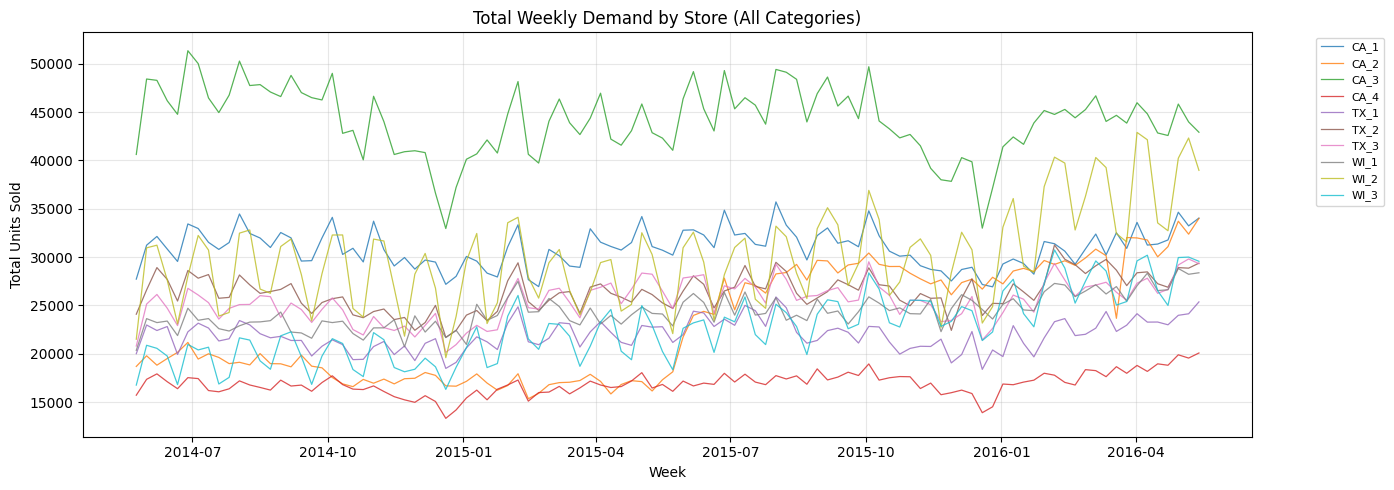

In [51]:
# Trend by store (aggregated across categories)
fig, ax = plt.subplots(figsize=(14, 5))

for store in sorted(weekly['store_id'].unique()):
    store_ts = weekly[weekly['store_id'] == store].groupby('week_start')['weekly_units'].sum().sort_index()
    ax.plot(store_ts.index, store_ts.values, label=store, linewidth=0.9, alpha=0.8)

ax.set_title('Total Weekly Demand by Store (All Categories)')
ax.set_xlabel('Week')
ax.set_ylabel('Total Units Sold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

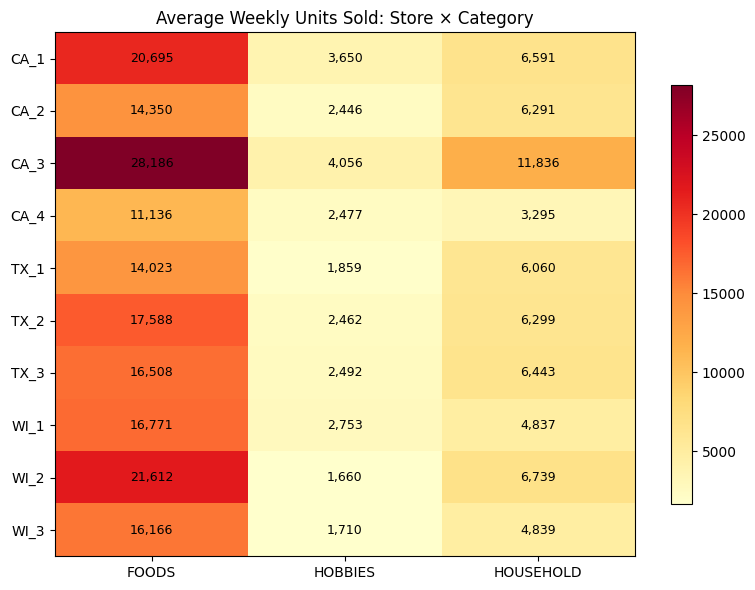

In [52]:
pivot = weekly.groupby(['store_id', 'cat_id'])['weekly_units'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# annotate each cell
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:,.0f}', ha='center', va='center', fontsize=9)

ax.set_title('Average Weekly Units Sold: Store × Category')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3.3 Seasonality & Day-of-Week Patterns

Let's look at the daily data briefly to understand within-week patterns, then check monthly seasonality at the weekly level.

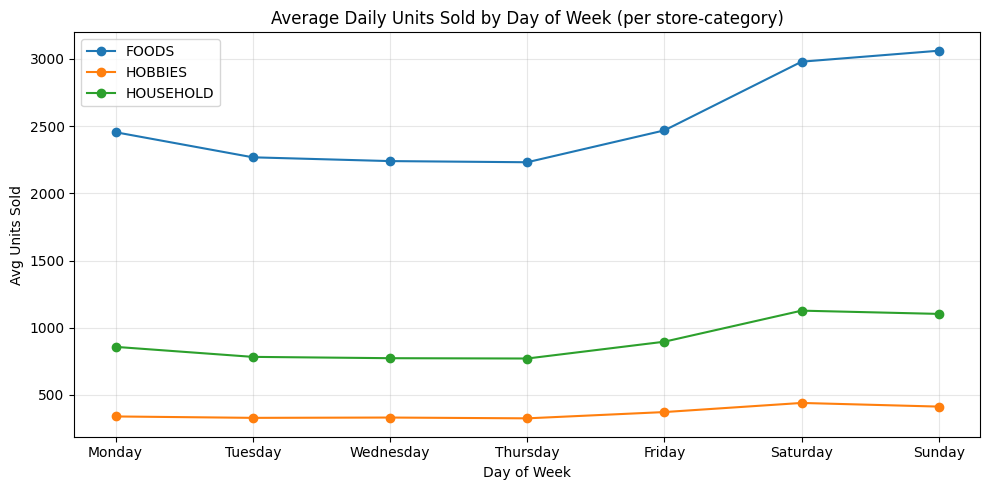

In [33]:
daily_recent = sales_long[sales_long['date'] >= cutoff].copy()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_by_dow = daily_recent.groupby(['cat_id', 'weekday'])['units_sold'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for cat in sorted(daily_by_dow['cat_id'].unique()):
    subset = daily_by_dow[daily_by_dow['cat_id'] == cat]
    subset = subset.set_index('weekday').reindex(day_order)
    ax.plot(subset.index, subset['units_sold'], marker='o', label=cat)

ax.set_title('Average Daily Units Sold by Day of Week (per store-category)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Units Sold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

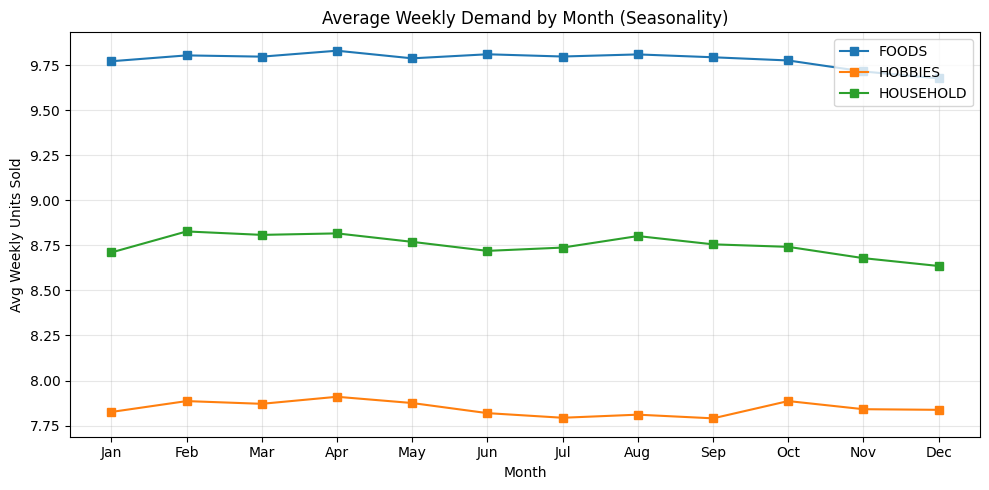

In [55]:
# Monthly seasonality at weekly level
weekly['month'] = weekly['week_start'].dt.month

fig, ax = plt.subplots(figsize=(10, 5))
for cat in sorted(weekly['cat_id'].unique()):
    monthly_avg = np.log(weekly[weekly['cat_id'] == cat].groupby('month')['weekly_units'].mean())
    ax.plot(monthly_avg.index, monthly_avg.values, marker='s', label=cat)

ax.set_title('Average Weekly Demand by Month (Seasonality)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Weekly Units Sold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Event & SNAP Impact on Demand

In [35]:
# Impact of events on daily sales (at store-category level)
daily_recent['has_event'] = daily_recent['event_name_1'].notna()

event_impact = daily_recent.groupby(['cat_id', 'has_event'])['units_sold'].mean().unstack()
event_impact.columns = ['No Event', 'Event Day']
event_impact['Lift %'] = ((event_impact['Event Day'] / event_impact['No Event']) - 1) * 100

event_impact.round(2)

,No Event,Event Day,Lift %
cat_id,,,
FOODS,2535.26,2458.84,-3.01
HOBBIES,367.42,337.27,-8.21
HOUSEHOLD,906.38,850.42,-6.17


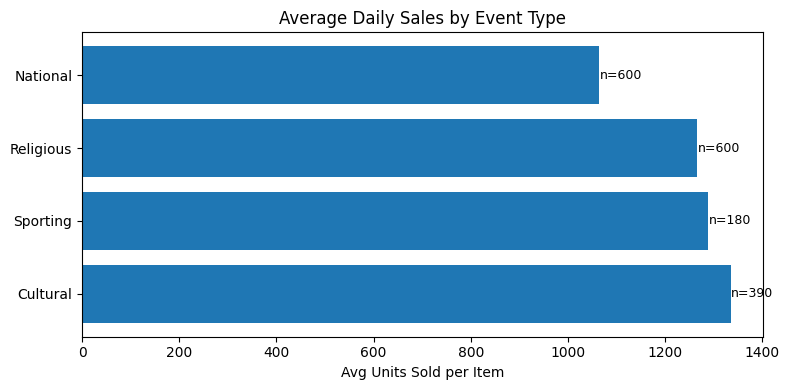

In [ ]:
# Demand by event type
event_type_avg = (
    daily_recent[daily_recent['has_event']]
    .groupby('event_type_1')['units_sold']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(event_type_avg.index, event_type_avg['mean'])
ax.set_xlabel('Avg Units Sold per Item')
ax.set_title('Average Daily Sales by Event Type')
for i, (val, cnt) in enumerate(zip(event_type_avg['mean'], event_type_avg['count'])):
    ax.text(val + 0.01, i, f'n={cnt:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Splitting into National vs. other event types (or just a is_national_holiday flag) would capture the real signal better.

In [38]:

#SNAP = Supplemental Nutrition Assistance Program
snap_cols = {'CA': 'snap_CA', 'TX': 'snap_TX', 'WI': 'snap_WI'}

snap_results = []
for state, col in snap_cols.items():
    state_data = daily_recent[daily_recent['state_id'] == state]
    avg_snap = state_data[state_data[col] == 1]['units_sold'].mean()
    avg_no_snap = state_data[state_data[col] == 0]['units_sold'].mean()
    snap_results.append({
        'State': state,
        'SNAP Day Avg': round(avg_snap, 1),
        'Non-SNAP Avg': round(avg_no_snap, 1),
        'Lift %': round((avg_snap / avg_no_snap - 1) * 100, 1)
    })

snap_df = pd.DataFrame(snap_results)
print("SNAP benefit day impact on daily sales (per store-category):")
snap_df

SNAP benefit day impact on daily sales (per store-category):


,State,SNAP Day Avg,Non-SNAP Avg,Lift %
0,CA,1430.8,1339.8,6.8
1,TX,1251.1,1130.7,10.6
2,WI,1382.4,1144.5,20.8


## 3.5 Price Analysis

In [39]:
item_cat = sales_train_eval[['item_id', 'cat_id', 'dept_id']].drop_duplicates()
prices_with_cat = sell_prices.merge(item_cat, on='item_id', how='left')

wk_range = weekly['wm_yr_wk'].unique()
prices_recent = prices_with_cat[prices_with_cat['wm_yr_wk'].isin(wk_range)]

prices_recent['sell_price'].describe()

count    3.106821e+06
mean     4.469174e+00
std      3.531867e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.480000e+00
75%      5.880000e+00
max      4.532000e+01
Name: sell_price, dtype: float64

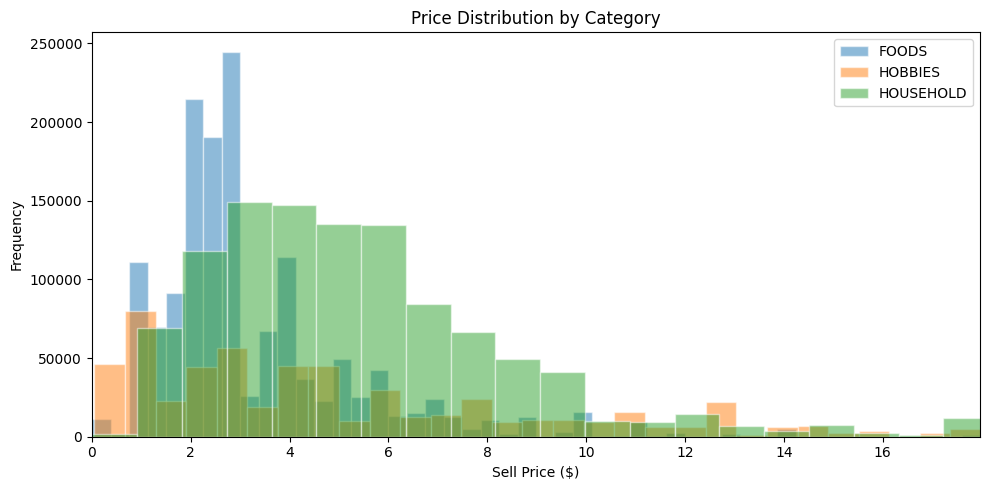

In [40]:
# Price distributions by category
fig, ax = plt.subplots(figsize=(10, 5))

for cat in sorted(prices_recent['cat_id'].unique()):
    data = prices_recent[prices_recent['cat_id'] == cat]['sell_price']
    ax.hist(data, bins=50, alpha=0.5, label=cat, edgecolor='white')

ax.set_title('Price Distribution by Category')
ax.set_xlabel('Sell Price ($)')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_xlim(0, prices_recent['sell_price'].quantile(0.99))  # trim extreme outliers for readability
plt.tight_layout()
plt.show()

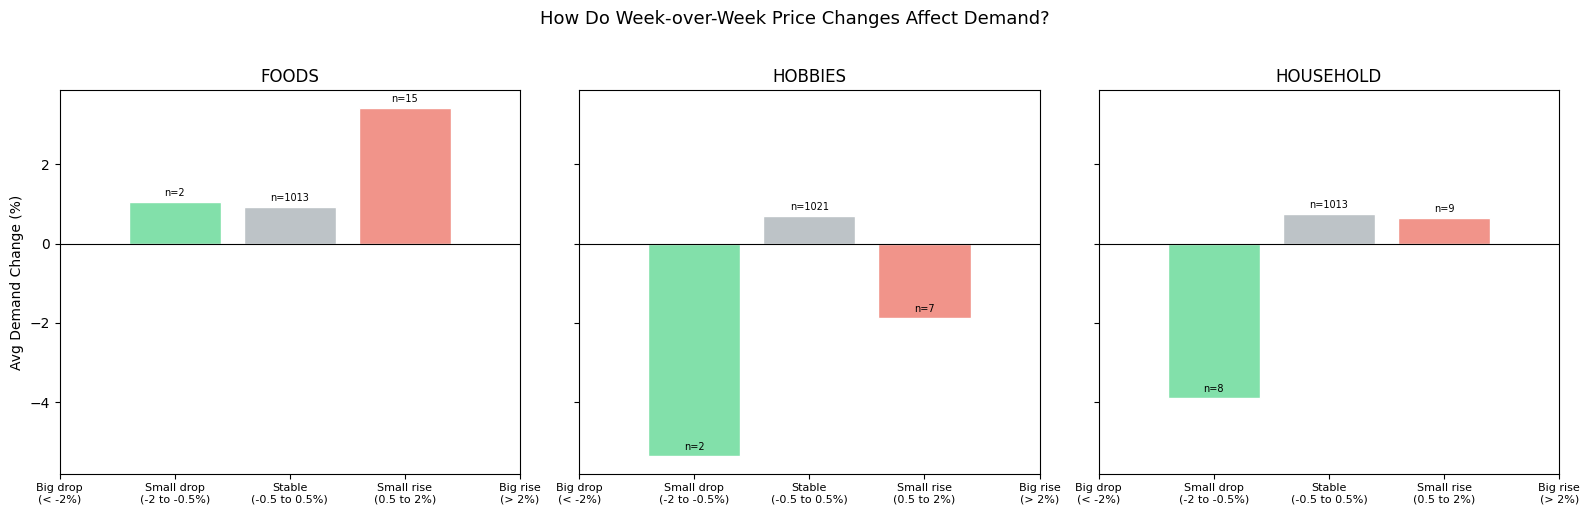

In [58]:
# Does a price increase reduce demand? (within each store-category)
avg_price_store_cat = (
    prices_recent
    .groupby(['store_id', 'cat_id', 'wm_yr_wk'])['sell_price']
    .mean()
    .reset_index()
    .rename(columns={'sell_price': 'avg_price'})
)

weekly_with_price = weekly.merge(avg_price_store_cat, on=['store_id', 'cat_id', 'wm_yr_wk'], how='left')
weekly_with_price = weekly_with_price.sort_values(['store_id', 'cat_id', 'week_start'])

weekly_with_price['price_pct_change'] = (
    weekly_with_price.groupby(['store_id', 'cat_id'])['avg_price'].pct_change() * 100
)
weekly_with_price['demand_pct_change'] = (
    weekly_with_price.groupby(['store_id', 'cat_id'])['weekly_units'].pct_change() * 100
)

# Bin price changes and show average demand response
changes = weekly_with_price.dropna(subset=['price_pct_change', 'demand_pct_change']).copy()
changes['price_bin'] = pd.cut(changes['price_pct_change'],
                              bins=[-float('inf'), -2, -0.5, 0.5, 2, float('inf')],
                              labels=['Big drop\n(< -2%)', 'Small drop\n(-2 to -0.5%)',
                                      'Stable\n(-0.5 to 0.5%)', 'Small rise\n(0.5 to 2%)',
                                      'Big rise\n(> 2%)'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, cat in zip(axes, sorted(changes['cat_id'].unique())):
    subset = changes[changes['cat_id'] == cat]
    grouped = subset.groupby('price_bin', observed=False)['demand_pct_change'].agg(['mean', 'count'])
    colors = ['#2ecc71', '#82e0aa', '#bdc3c7', '#f1948a', '#e74c3c']
    bars = ax.bar(range(len(grouped)), grouped['mean'], color=colors, edgecolor='white')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped.index, fontsize=8)
    ax.set_title(cat)
    ax.axhline(0, color='black', linewidth=0.8)
    for i, (val, cnt) in enumerate(zip(grouped['mean'], grouped['count'])):
        ax.text(i, val + 0.1, f'n={cnt}', ha='center', fontsize=7, va='bottom')

axes[0].set_ylabel('Avg Demand Change (%)')
fig.suptitle('How Do Week-over-Week Price Changes Affect Demand?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3.6 Correlation & Relationships

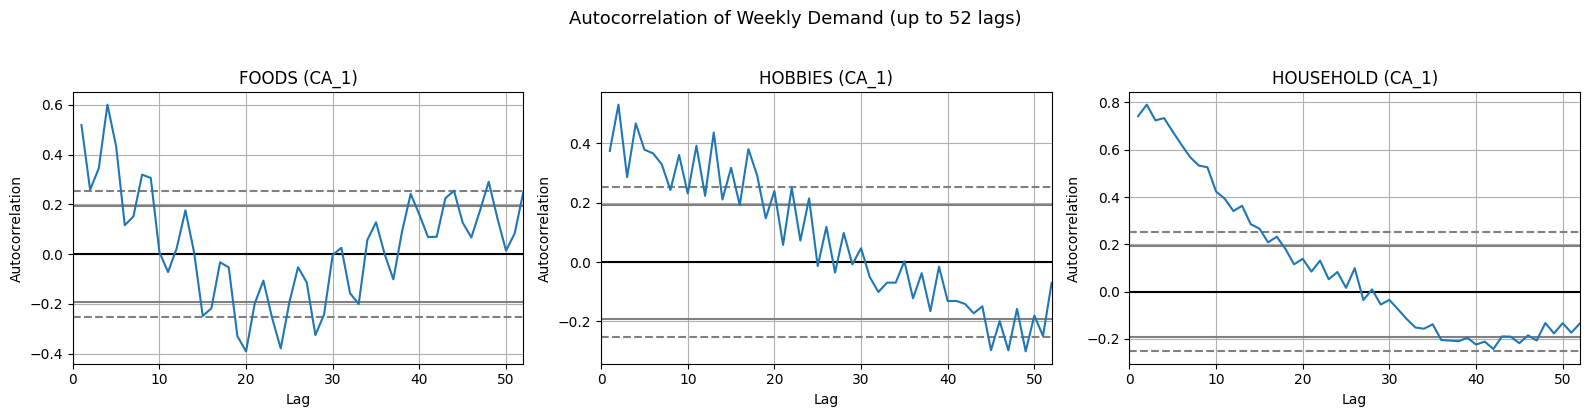

In [ ]:
# Autocorrelation of weekly demand — how predictive is last week's demand?
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, cat in zip(axes, sorted(weekly['cat_id'].unique())):
    # pick one representative store-category series
    example = (weekly[(weekly['cat_id'] == cat) & (weekly['store_id'] == 'CA_1')]
               .sort_values('week_start')['weekly_units'])
    autocorrelation_plot(example, ax=ax)
    ax.set_title(f'{cat} (CA_1)')
    ax.set_xlim(0, 52)

fig.suptitle('Autocorrelation of Weekly Demand (up to 52 lags)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 3.7 Coefficient of Variation — Which Store-Category Combos Are Hardest to Predict?

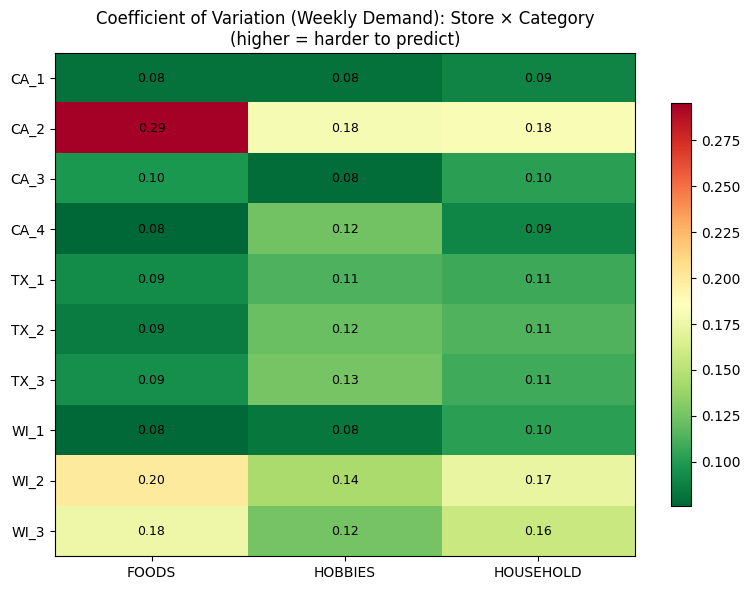

In [46]:
cv = (
    weekly
    .groupby(['store_id', 'cat_id'])['weekly_units']
    .agg(['mean', 'std'])
)
cv['cv'] = cv['std'] / cv['mean']
cv = cv.round(3)

cv_pivot = cv['cv'].unstack()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cv_pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(cv_pivot.columns)))
ax.set_xticklabels(cv_pivot.columns)
ax.set_yticks(range(len(cv_pivot.index)))
ax.set_yticklabels(cv_pivot.index)

for i in range(len(cv_pivot.index)):
    for j in range(len(cv_pivot.columns)):
        ax.text(j, i, f'{cv_pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Coefficient of Variation (Weekly Demand): Store × Category\n(higher = harder to predict)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3.8 Key Takeaways


- **Scale differences**: FOODS dominates in volume.
- **Seasonality**: Don't see any clear patterns
- **Day-of-week**: Friday seems to have a positive impact on sales
- **Events & SNAP**: Events seem to be lost in the weekly data, SNAP shows an important impact!
- **Price sensitivity**: price might still be useful as a slow-moving feature (e.g., monthly average or trend) rather than a week-to-week signal. The lag features and seasonality will likely do the heavy lifting.
- **Autocorrelation**: 1. Lag-1 feature (last week's demand) will be valuable across all categories, especially Household
                       2. For Foods, a lag-2 feature could help capture that biweekly pattern
                       3. Hobbies will likely need more external features (events, prices) to compensate for weaker autocorrelation
- **Volatility (CV)**: CA-2 has the highest volatility

In [ ]:
weekly.to_csv('clean_data/weekly_agg_sales.csv',index=False)